# Notebook 3: Baseline Models

## Objective

Before proposing a novel neural architecture, it is essential to establish strong baseline models.

Each model will be trained and evaluated using the same dataset generated in the previous notebooks.

The baselines include:

- Linear Regression
- Random Forest
- XGBoost
- LSTM
- GRU
- Vanilla Transformer

Performance will later be compared against the proposed Price-Aware Feedback Transformer.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import random
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", DEVICE)

Using: cuda


In [3]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

Torch: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
Device count: 1


In [4]:
X_train = np.load("pipeline/X_train.npy")
X_val = np.load("pipeline/X_val.npy")
X_test = np.load("pipeline/X_test.npy")

y_train = np.load("pipeline/y_train.npy")
y_val = np.load("pipeline/y_val.npy")
y_test = np.load("pipeline/y_test.npy")

feature_columns = joblib.load("pipeline/feature_columns.pkl")

In [5]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1844, 60, 95)
(348, 60, 95)
(349, 60, 95)


# Baseline 1: Linear Regression

Since Linear Regression expects tabular input, each sequence is flattened into a single feature vector.

In [6]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

In [7]:
lr = LinearRegression()
lr.fit(X_train_flat, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5700,)","[-0. ,-0. ,-0. ,...,-0.02, 0. , 0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.001952
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5700
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1843
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1844,)","[1930.09, 847.29, 646.24,..., 0.34, 0.32, 0. ]"


In [8]:
pred_lr = lr.predict(X_test_flat)

In [9]:
mae = mean_absolute_error(y_test, pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, pred_lr))
r2 = r2_score(y_test, pred_lr)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.1887415778195752
RMSE: 0.24870635983747824
R²  : -33.790931402341535


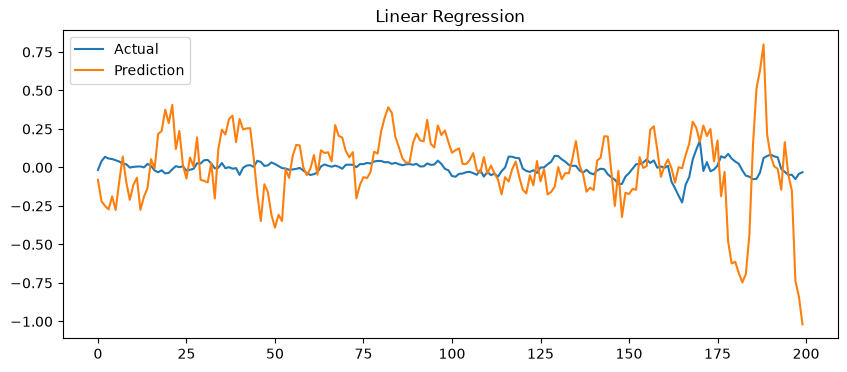

In [10]:
plt.figure(figsize=(10,4))
plt.plot(y_test[:200], label="Actual")
plt.plot(pred_lr[:200], label="Prediction")
plt.title("Linear Regression")
plt.legend()
plt.show()

# Baseline 2: Random Forest

Random Forest captures nonlinear feature interactions and serves as a strong tabular learning baseline.

In [11]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_flat, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [12]:
pred_rf = rf.predict(X_test_flat)

In [13]:
mae = mean_absolute_error(y_test, pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
r2 = r2_score(y_test, pred_rf)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.03304963159418031
RMSE: 0.0451353963796831
R²  : -0.1458474301465933


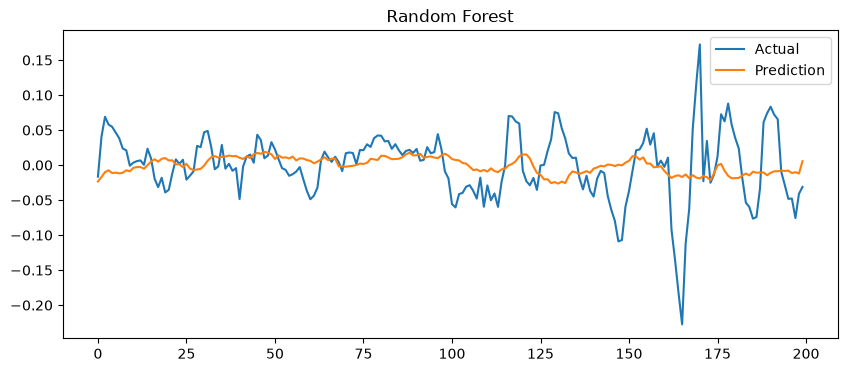

In [14]:
plt.figure(figsize=(10,4))
plt.plot(y_test[:200], label="Actual")
plt.plot(pred_rf[:200], label="Prediction")
plt.title("Random Forest")
plt.legend()
plt.show()

In [15]:
results = pd.DataFrame(columns=[
    "Model",
    "MAE",
    "RMSE",
    "R2"
])

In [16]:
results.loc[len(results)] = [
    "Linear Regression",
    mean_absolute_error(y_test, pred_lr),
    np.sqrt(mean_squared_error(y_test, pred_lr)),
    r2_score(y_test, pred_lr)
]

results.loc[len(results)] = [
    "Random Forest",
    mean_absolute_error(y_test, pred_rf),
    np.sqrt(mean_squared_error(y_test, pred_rf)),
    r2_score(y_test, pred_rf)
]

In [17]:
results

,Model,MAE,RMSE,R2
0,Linear Regression,0.188742,0.248706,-33.790931
1,Random Forest,0.033050,0.045135,-0.145847


# PyTorch Dataset and DataLoader

The datasets generated in Notebook 2 are wrapped into PyTorch DataLoaders.

These loaders efficiently feed mini-batches to neural network models during training.

In [18]:
class StockDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [19]:
train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)
test_dataset = StockDataset(X_test, y_test)

In [20]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [21]:
X_batch, y_batch = next(iter(train_loader))

print(X_batch.shape)
print(y_batch.shape)

torch.Size([64, 60, 95])
torch.Size([64])


# LSTM Baseline

Long Short-Term Memory (LSTM) networks are widely used for sequential financial forecasting.

This model serves as the primary deep learning baseline before evaluating more advanced Transformer architectures.

In [22]:
class LSTMModel(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)
        output = hidden[-1]
        output = self.fc(output)
        return output.squeeze()

In [23]:
model = LSTMModel(X_train.shape[2]).to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [24]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()
    running_loss = 0
    for X, y in loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

In [25]:
@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0
    predictions = []
    targets = []
    for X, y in loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)
        pred = model(X)
        loss = criterion(pred, y)
        running_loss += loss.item()
        predictions.extend(pred.cpu().numpy())
        targets.extend(y.cpu().numpy())
    return (
        running_loss / len(loader),
        np.array(predictions),
        np.array(targets)
    )

In [26]:
EPOCHS = 30

train_loss_history = []
val_loss_history = []

In [27]:
best_loss = float("inf")
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, _, _ = validate(
        model,
        val_loader,
        criterion
    )

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_lstm.pth")

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train {train_loss:.6f} | "
        f"Val {val_loss:.6f}"
    )

Epoch 01/30 | Train 0.002218 | Val 0.001128
Epoch 02/30 | Train 0.001352 | Val 0.001053
Epoch 03/30 | Train 0.001272 | Val 0.001577
Epoch 04/30 | Train 0.001116 | Val 0.001643
Epoch 05/30 | Train 0.001003 | Val 0.001401
Epoch 06/30 | Train 0.000927 | Val 0.001490
Epoch 07/30 | Train 0.000781 | Val 0.002918
Epoch 08/30 | Train 0.000735 | Val 0.001907
Epoch 09/30 | Train 0.000660 | Val 0.001673
Epoch 10/30 | Train 0.000674 | Val 0.001704
Epoch 11/30 | Train 0.000562 | Val 0.001436
Epoch 12/30 | Train 0.000506 | Val 0.001928
Epoch 13/30 | Train 0.000455 | Val 0.002121
Epoch 14/30 | Train 0.000414 | Val 0.001934
Epoch 15/30 | Train 0.000391 | Val 0.001797
Epoch 16/30 | Train 0.000353 | Val 0.001775
Epoch 17/30 | Train 0.000351 | Val 0.001507
Epoch 18/30 | Train 0.000321 | Val 0.001684
Epoch 19/30 | Train 0.000323 | Val 0.001891
Epoch 20/30 | Train 0.000298 | Val 0.001762
Epoch 21/30 | Train 0.000302 | Val 0.002035
Epoch 22/30 | Train 0.000243 | Val 0.001625
Epoch 23/30 | Train 0.000244 | V

In [28]:
model.load_state_dict(torch.load("best_lstm.pth", weights_only=True))

<All keys matched successfully>

In [29]:
test_loss, pred_lstm, true_lstm = validate(
    model,
    test_loader,
    criterion
)

In [30]:
mae = mean_absolute_error(true_lstm, pred_lstm)
rmse = np.sqrt(mean_squared_error(true_lstm, pred_lstm))
r2 = r2_score(true_lstm, pred_lstm)

print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²  : {r2:.6f}")

MAE : 0.040036
RMSE: 0.052256
R²  : -0.535912


In [31]:
results.loc[len(results)] = ["LSTM", mae, rmse, r2]
results

,Model,MAE,RMSE,R2
0,Linear Regression,0.188742,0.248706,-33.790931
1,Random Forest,0.033050,0.045135,-0.145847
2,LSTM,0.040036,0.052256,-0.535912


# Baseline 4: GRU

The Gated Recurrent Unit (GRU) is a simplified recurrent neural network that uses fewer parameters than an LSTM while retaining the ability to model temporal dependencies.

GRUs often train faster and can generalize better on noisy financial time series.

In [32]:
class GRUModel(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        output, hidden = self.gru(x)
        output = hidden[-1]
        output = self.fc(output)
        return output.squeeze()

In [33]:
gru = GRUModel(X_train.shape[2]).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru.parameters(), lr=1e-3)

In [34]:
best_loss = float("inf")
train_history = []
val_history = []
EPOCHS = 30

In [35]:
for epoch in range(EPOCHS):

    train_loss = train_one_epoch(gru, train_loader, criterion, optimizer)
    val_loss, _, _ = validate(gru, val_loader, criterion)

    train_history.append(train_loss)
    val_history.append(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(gru.state_dict(), "best_gru.pth")

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train {train_loss:.6f} | Val {val_loss:.6f}")

Epoch 01/30 | Train 0.007062 | Val 0.001354
Epoch 02/30 | Train 0.001776 | Val 0.001791
Epoch 03/30 | Train 0.001514 | Val 0.001272
Epoch 04/30 | Train 0.001317 | Val 0.001229
Epoch 05/30 | Train 0.001201 | Val 0.001609
Epoch 06/30 | Train 0.001112 | Val 0.001425
Epoch 07/30 | Train 0.001031 | Val 0.001516
Epoch 08/30 | Train 0.001017 | Val 0.001781
Epoch 09/30 | Train 0.001005 | Val 0.002417
Epoch 10/30 | Train 0.000862 | Val 0.001617
Epoch 11/30 | Train 0.000819 | Val 0.002875
Epoch 12/30 | Train 0.000782 | Val 0.001728
Epoch 13/30 | Train 0.000763 | Val 0.002586
Epoch 14/30 | Train 0.000766 | Val 0.001895
Epoch 15/30 | Train 0.000783 | Val 0.002079
Epoch 16/30 | Train 0.000655 | Val 0.001877
Epoch 17/30 | Train 0.000603 | Val 0.001817
Epoch 18/30 | Train 0.000566 | Val 0.002089
Epoch 19/30 | Train 0.000563 | Val 0.001834
Epoch 20/30 | Train 0.000561 | Val 0.002164
Epoch 21/30 | Train 0.000576 | Val 0.002039
Epoch 22/30 | Train 0.000506 | Val 0.002156
Epoch 23/30 | Train 0.000459 | V

In [36]:
gru.load_state_dict(torch.load("best_gru.pth", weights_only=True))

<All keys matched successfully>

In [37]:
_, pred_gru, true_gru = validate(gru, test_loader, criterion)

In [38]:
mae = mean_absolute_error(true_gru, pred_gru)
rmse = np.sqrt(mean_squared_error(true_gru, pred_gru))
r2 = r2_score(true_gru, pred_gru)

print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²  : {r2:.6f}")

MAE : 0.034453
RMSE: 0.047614
R²  : -0.275127


In [39]:
results.loc[len(results)] = ["GRU", mae, rmse, r2]
results

,Model,MAE,RMSE,R2
0,Linear Regression,0.188742,0.248706,-33.790931
1,Random Forest,0.033050,0.045135,-0.145847
2,LSTM,0.040036,0.052256,-0.535912
3,GRU,0.034453,0.047614,-0.275127


# Baseline 5: XGBoost

Gradient-boosted decision trees are among the strongest baselines for tabular financial datasets.

They capture nonlinear feature interactions and often outperform deep learning models on engineered features.

In [40]:
from xgboost import XGBRegressor

In [41]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

In [42]:
xgb.fit(
    X_train_flat,
    y_train,
    eval_set=[(X_val_flat, y_val)],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [43]:
pred_xgb = xgb.predict(X_test_flat)

In [44]:
mae = mean_absolute_error(y_test, pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2 = r2_score(y_test, pred_xgb)

print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²  : {r2:.6f}")

MAE : 0.034423
RMSE: 0.045011
R²  : -0.139553


In [ ]:
results.loc[len(results)] = ["XGBoost", mae, rmse, r2]
results.sort_values("MAE")

,Model,MAE,RMSE,R2
1,Random Forest,0.033050,0.045135,-0.145847
4,XGBoost,0.034423,0.045011,-0.139553
3,GRU,0.034453,0.047614,-0.275127
2,LSTM,0.040036,0.052256,-0.535912
0,Linear Regression,0.188742,0.248706,-33.790931


In [46]:
def evaluate_trading_metrics(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    direction_acc = np.mean(np.sign(y_true) == np.sign(y_pred))

    hit_rate = np.mean((y_true * y_pred) > 0)

    strategy_returns = np.sign(y_pred) * y_true

    cumulative_returns = np.cumprod(1 + strategy_returns)

    sharpe = (
        strategy_returns.mean()
        /
        (strategy_returns.std() + 1e-9)
    ) * np.sqrt(252)

    running_max = np.maximum.accumulate(cumulative_returns)

    drawdown = (
        cumulative_returns - running_max
    ) / running_max

    max_drawdown = drawdown.min()

    total_return = cumulative_returns[-1] - 1

    return {
        "Directional Accuracy": direction_acc,
        "Hit Rate": hit_rate,
        "Sharpe": sharpe,
        "Strategy Return": total_return,
        "Max Drawdown": max_drawdown
    }

In [47]:
rf_metrics = evaluate_trading_metrics(y_test, pred_rf)

rf_metrics

{'Directional Accuracy': np.float64(0.5157593123209169),
 'Hit Rate': np.float64(0.5157593123209169),
 'Sharpe': np.float64(0.33400021653341516),
 'Strategy Return': np.float64(0.001970351412418969),
 'Max Drawdown': np.float64(-0.675468111922626)}

In [48]:
lstm_metrics = evaluate_trading_metrics(true_lstm, pred_lstm)

lstm_metrics

{'Directional Accuracy': np.float64(0.4785100286532951),
 'Hit Rate': np.float64(0.4785100286532951),
 'Sharpe': np.float64(-0.14269605091713897),
 'Strategy Return': np.float32(-0.3573643),
 'Max Drawdown': np.float32(-0.7827261)}

In [49]:
gru_metrics = evaluate_trading_metrics(true_gru, pred_gru)

gru_metrics

{'Directional Accuracy': np.float64(0.5787965616045845),
 'Hit Rate': np.float64(0.5787965616045845),
 'Sharpe': np.float64(2.78905939206099),
 'Strategy Return': np.float32(8.535793),
 'Max Drawdown': np.float32(-0.70374465)}

In [50]:
xgb_metrics = evaluate_trading_metrics(y_test, pred_xgb)

xgb_metrics

{'Directional Accuracy': np.float64(0.4899713467048711),
 'Hit Rate': np.float64(0.4899713467048711),
 'Sharpe': np.float64(-0.13255239732949578),
 'Strategy Return': np.float64(-0.35080267614888583),
 'Max Drawdown': np.float64(-0.741018589423618)}

In [73]:
lr_metrics = evaluate_trading_metrics(y_test, pred_lr)

In [79]:
trading_results = pd.DataFrame({
    "Model":["Linear Regression", "Random Forest", "XGBoost","LSTM","GRU"],
    "Directional Accuracy":[
        lr_metrics["Directional Accuracy"],
        rf_metrics["Directional Accuracy"],
        xgb_metrics["Directional Accuracy"],
        lstm_metrics["Directional Accuracy"],
        gru_metrics["Directional Accuracy"]
    ],
    "Hit Rate":[
        lr_metrics["Hit Rate"],
        rf_metrics["Hit Rate"],
        xgb_metrics["Hit Rate"],
        lstm_metrics["Hit Rate"],
        gru_metrics["Hit Rate"]
    ],
    "Sharpe":[
        lr_metrics["Sharpe"],
        rf_metrics["Sharpe"],
        xgb_metrics["Sharpe"],
        lstm_metrics["Sharpe"],
        gru_metrics["Sharpe"]
    ],
    "Strategy Return":[
        lr_metrics["Strategy Return"],
        rf_metrics["Strategy Return"],
        xgb_metrics["Strategy Return"],
        lstm_metrics["Strategy Return"],
        gru_metrics["Strategy Return"]
    ],
    "Max Drawdown":[
        lr_metrics["Max Drawdown"],
        rf_metrics["Max Drawdown"],
        xgb_metrics["Max Drawdown"],
        lstm_metrics["Max Drawdown"],
        gru_metrics["Max Drawdown"]
    ]
})

trading_results

,Model,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown
0,Linear Regression,0.467049,0.467049,-0.398144,-0.494425,-0.694398
1,Random Forest,0.515759,0.515759,0.334000,0.001970,-0.675468
2,XGBoost,0.489971,0.489971,-0.132552,-0.350803,-0.741019
3,LSTM,0.478510,0.478510,-0.142696,-0.357364,-0.782726
4,GRU,0.578797,0.578797,2.789059,8.535793,-0.703745


# Save Results

Persist baseline metrics so future notebooks can load and extend them.

In [80]:
results.to_csv(
    "experiments/baseline_results.csv",
    index=False
)

trading_results.to_csv(
    "experiments/trading_results.csv",
    index=False
)

In [81]:
experiment_log = pd.DataFrame(columns=[
    "Experiment",
    "Model",
    "Parameters",
    "Train Time (s)",
    "Epochs",
    "MAE",
    "RMSE",
    "R2",
    "Directional Accuracy",
    "Hit Rate",
    "Sharpe",
    "Strategy Return",
    "Max Drawdown",
    "Notes"
])

In [82]:
for i in range(len(results)):

    row = {
        "Experiment":"Baseline",
        "Model":results.iloc[i]["Model"],
        "Parameters":None,
        "Train Time (s)":None,
        "Epochs":None,
        "MAE":results.iloc[i]["MAE"],
        "RMSE":results.iloc[i]["RMSE"],
        "R2":results.iloc[i]["R2"],
        "Directional Accuracy": trading_results.iloc[i]["Directional Accuracy"],
        "Hit Rate":trading_results.iloc[i]["Hit Rate"],
        "Sharpe":trading_results.iloc[i]["Sharpe"],
        "Strategy Return":trading_results.iloc[i]["Strategy Return"],
        "Max Drawdown":trading_results.iloc[i]["Max Drawdown"],
        "Notes":"Baseline"
    }

    experiment_log.loc[len(experiment_log)] = row

In [83]:
experiment_log.to_csv(
    "experiments/experiment_log.csv",
    index=False
)
experiment_log

,Experiment,Model,Parameters,Train Time (s),Epochs,MAE,RMSE,R2,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown,Notes
0,Baseline,Linear Regression,None,None,None,0.188742,0.248706,-33.790931,0.467049,0.467049,-0.398144,-0.494425,-0.694398,Baseline
1,Baseline,Random Forest,None,None,None,0.033050,0.045135,-0.145847,0.515759,0.515759,0.334000,0.001970,-0.675468,Baseline
2,Baseline,LSTM,None,None,None,0.040036,0.052256,-0.535912,0.489971,0.489971,-0.132552,-0.350803,-0.741019,Baseline
3,Baseline,GRU,None,None,None,0.034453,0.047614,-0.275127,0.478510,0.478510,-0.142696,-0.357364,-0.782726,Baseline
4,Baseline,XGBoost,None,None,None,0.034423,0.045011,-0.139553,0.578797,0.578797,2.789059,8.535793,-0.703745,Baseline
